# Winner dispersion across election sizes

The nested Monte Carlo of `01-Introduction.ipynb`, run over a grid of candidate
counts `C` and voter counts `V`: the outer loop draws a candidate configuration,
the inner loop redraws voters against that fixed configuration.

Two rules only - plurality and Borda. Veto is left out deliberately: it ties
essentially always past a handful of candidates, so at `C = 100` there would be
nothing left to measure.

Tied elections are excluded throughout. `Tally.winner_index` falls back to the
lowest index when the top score is shared, which is an artefact of list order
rather than an outcome - the distance to such a "winner" means nothing.

In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

In [2]:
from voting import (
    Candidate,
    Voter,
    Election,
    ElectionResult,
    ResultsAnalyzer,
    PluralityRule,
    BordaRule,
    VetoRule
)

from voting.plotting import (
    plot_winner_distances,
    random_2d_point,
)

RULES = [PluralityRule(), BordaRule()]

If we were to add Veto rule as well, the only configurations without ties would be those with five candidates. If there are more than five candidates, the election results are not decisive.

In [3]:
from collections import defaultdict


C_values = [5, 10, 25, 50, 100]
V_values = [25, 50, 100, 200, 500]
N_CONFIGS = 20  # candidate configurations per (C, V)
N_VOTER_SAMPLES = 10  # voter draws per candidate configuration
MIN_RATIO = 4  # only keep (C, V) cells with at least this many voters per candidate

# nested_results[(C, V)] = list of groups; each group = list of decisive
# ElectionResult sharing one candidate configuration but different voter draws.
# Ties are dropped as they are drawn rather than filtered downstream, so every
# number further down is computed over decisive elections only.
nested_results: dict[tuple, list[list[ElectionResult]]] = defaultdict(list)
decisive_counts: dict[tuple, tuple[int, int]] = {}  # (C, V) -> (kept, drawn)

n_total = 0
n_tied = 0

for C in C_values:
    for V in V_values:
        # skip degenerate regime where plurality is structurally tied
        if ( V / C < MIN_RATIO):
            continue
        cell_total = 0
        cell_tied = 0
        for _ in range(N_CONFIGS):
            candidates = [
                Candidate(id=id, position=random_2d_point()) for id in range(C)
            ]

            group: list[ElectionResult] = []
            for _ in range(N_VOTER_SAMPLES):
                voters = [Voter(position=random_2d_point()) for _ in range(V)]
                election = Election(candidates=candidates, voters=voters)
                result = election.compare(RULES)

                cell_total += 1
                if result.has_tie():
                    cell_tied += 1
                else:
                    group.append(result)

            if group:  # a configuration can lose every draw to ties
                nested_results[(C, V)].append(group)

        decisive_counts[(C, V)] = (cell_total - cell_tied, cell_total)
        n_total += cell_total
        n_tied += cell_tied

n_configs_kept = sum(len(groups) for groups in nested_results.values())

print(f"tied (excluded): {n_tied}/{n_total} ({n_tied / n_total:.1%})")
print(f"decisive (kept): {n_total - n_tied}")
print(
    f"configurations with at least one decisive draw: "
    f"{n_configs_kept}/{len(decisive_counts) * N_CONFIGS}"
)

tied (excluded): 274/3000 (9.1%)
decisive (kept): 2726
configurations with at least one decisive draw: 300/300


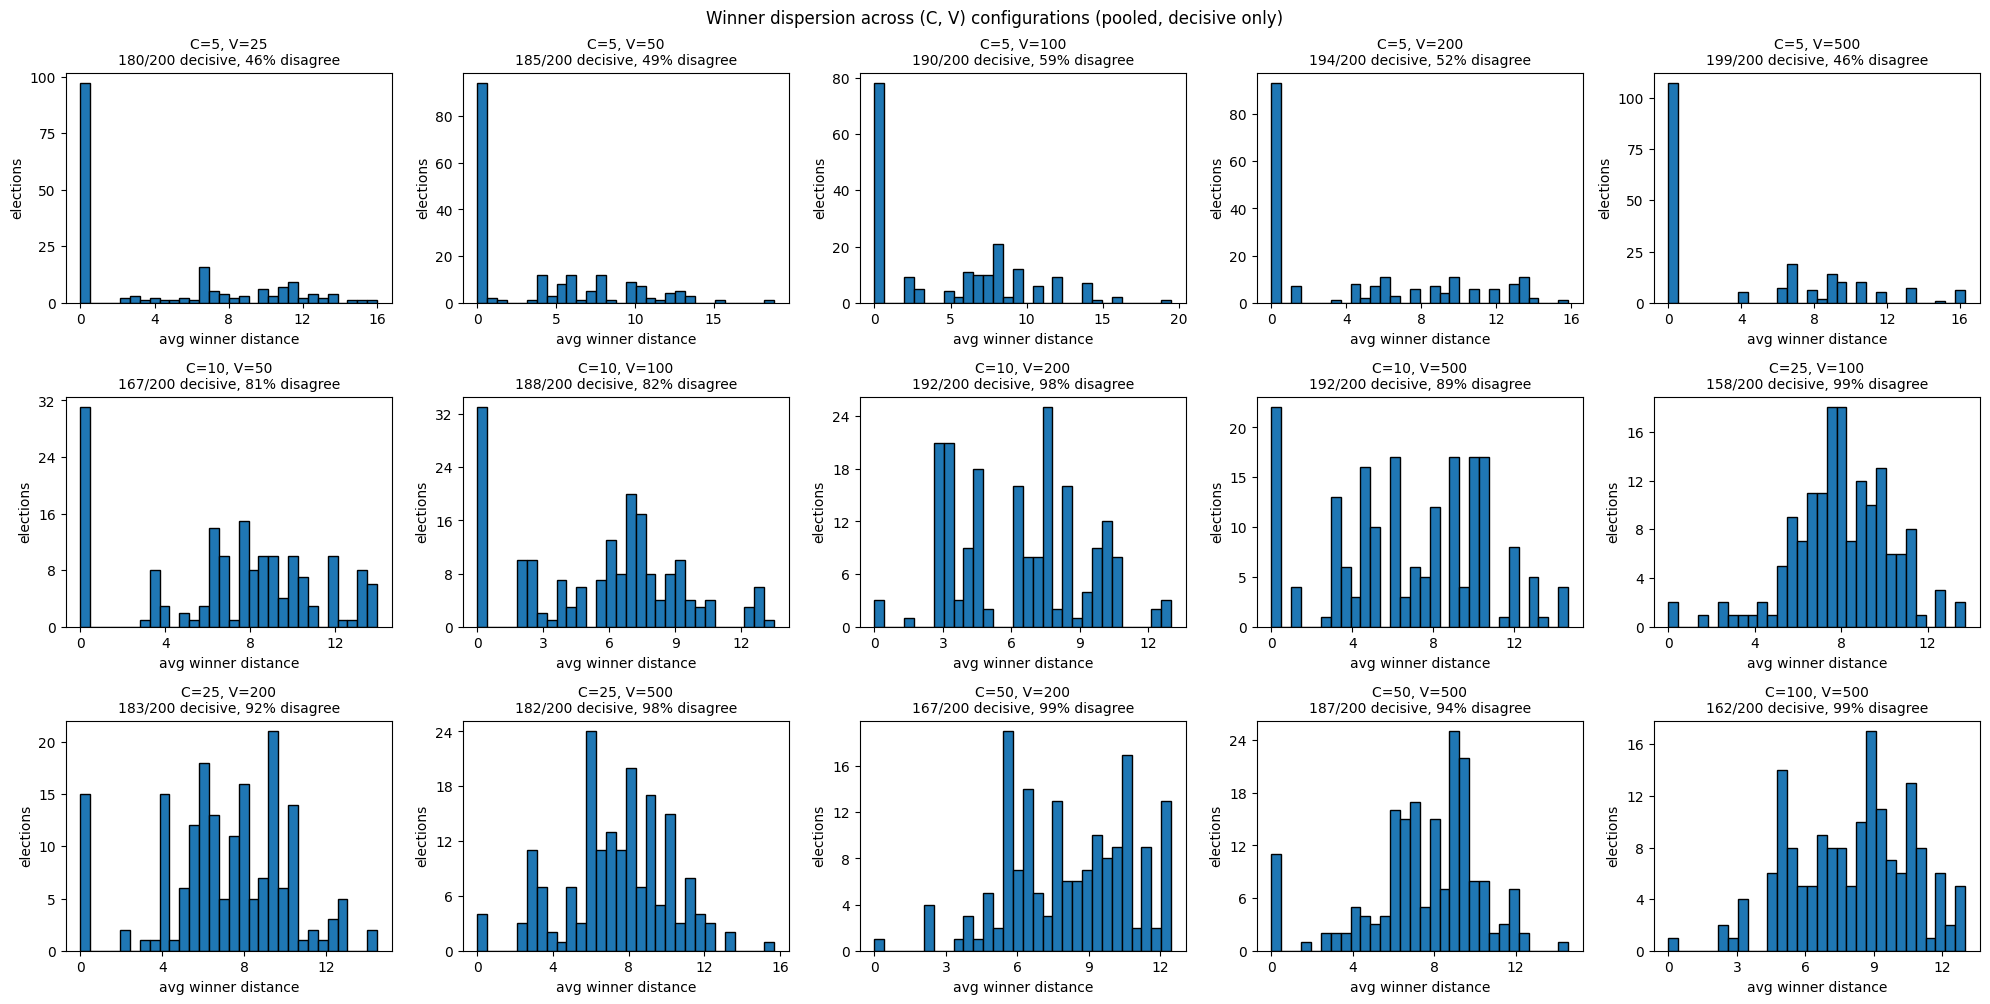

In [4]:
# Only the (C, V) cells that were actually generated (V/C >= MIN_RATIO), packed
# into a compact grid with no empty gaps. Set N_COLS = len(cells) for a single row.
cells = [(C, V) for C in C_values for V in V_values if nested_results[(C, V)]]

N_COLS = 5
n_rows = (len(cells) // N_COLS)  # ceil division

fig, axes = plt.subplots(
    n_rows, N_COLS, figsize=(4 * N_COLS, 3.4 * n_rows), squeeze=False
)
for ax in axes.flat:
    ax.axis("off")  # hide leftover slots; switch on only the ones we fill

for k, (C, V) in enumerate(cells):
    ax = axes[k // N_COLS][k % N_COLS]
    ax.axis("on")
    flat = [r for group in nested_results[(C, V)] for r in group]
    analyzer = ResultsAnalyzer(flat)
    distances = analyzer.winner_distance_series()
    kept, drawn = decisive_counts[(C, V)]

    plot_winner_distances(distances, bins=30, ax=ax)
    ax.set_title(
        f"C={C}, V={V}\n{kept}/{drawn} decisive, "
        f"{analyzer.disagreement_rate():.0%} disagree",
        fontsize=10,
    )
    ax.set_xlabel("avg winner distance")
    ax.set_ylabel("elections")

fig.suptitle("Winner dispersion across (C, V) configurations (pooled, decisive only)")
fig.tight_layout()
plt.show()

The bar at zero is the elections where plurality and Borda picked the same
candidate, so the distance is exactly `0.0`. It is a point mass sitting on top of
a continuous distribution, which is why that one bin can tower over every other
while still holding a minority of the elections - read its height against the
`disagree` figure in the title, not against the neighbouring bars.

In [5]:
# Per (C, V), over decisive elections only:
# - decisive: draws kept once ties were dropped
# - disagree: share of those where plurality and Borda parted ways
# - between:  std of per-config means (sensitivity to candidate placement)
# - within:   mean of per-config stds  (sensitivity to voter draw, candidates fixed)
print(
    f"{'C':>5} {'V':>5} {'decisive':>10} {'disagree':>9} "
    f"{'mean':>8} {'between':>9} {'within':>8}"
)
for C in C_values:
    for V in V_values:
        groups = nested_results[(C, V)]
        if not groups:  # cell skipped (V/C below MIN_RATIO)
            continue
        series = [ResultsAnalyzer(g).winner_distance_series() for g in groups]
        per_config_means = [float(np.mean(s)) for s in series]
        per_config_stds = [float(np.std(s)) for s in series]

        flat = [r for group in groups for r in group]
        kept, drawn = decisive_counts[(C, V)]
        print(
            f"{C:>5} {V:>5} "
            f"{f'{kept}/{drawn}':>10} "
            f"{ResultsAnalyzer(flat).disagreement_rate():>8.0%} "
            f"{np.mean(per_config_means):>8.3f} "
            f"{np.std(per_config_means):>9.3f} "
            f"{np.mean(per_config_stds):>8.3f}"
        )

    C     V   decisive  disagree     mean   between   within
    5    25    180/200      46%    4.165     3.405    3.214
    5    50    185/200      49%    3.926     3.303    2.440
    5   100    190/200      59%    4.821     2.914    3.266
    5   200    194/200      52%    4.525     3.862    2.608
    5   500    199/200      46%    4.298     4.363    1.615
   10    50    167/200      81%    7.019     2.017    3.354
   10   100    188/200      82%    5.662     2.345    2.315
   10   200    192/200      98%    6.385     2.056    1.457
   10   500    192/200      89%    6.767     3.226    1.304
   25   100    158/200      99%    8.056     0.910    1.945
   25   200    183/200      92%    7.096     1.779    2.379
   25   500    182/200      98%    7.352     1.508    2.149
   50   200    167/200      99%    8.265     1.368    2.051
   50   500    187/200      94%    7.513     1.394    2.193
  100   500    162/200      99%    8.075     1.435    1.923
